# Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

In [ ]:
xls = pd.ExcelFile("../data/raw/ethiopia_fi_unified_data.xlsx")

data = pd.read_excel("../data/raw/ethiopia_fi_unified_data.xlsx", sheet_name="ethiopia_fi_unified_data")

impact_links = pd.read_excel("../data/raw/ethiopia_fi_unified_data.xlsx", sheet_name="Impact_sheet")

reference = pd.read_excel("../data/raw/reference_codes.xlsx")

print("Dataset shape:", data.shape)
print("Reference codes shape:", reference.shape)

Dataset shape: (43, 34)
Reference codes shape: (71, 4)


## Preview Dataset

In [3]:
data.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [4]:
impact_links.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [5]:
reference.head()

,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All


## Schema Validation

In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            43 non-null     object        
 1   record_type          43 non-null     object        
 2   category             10 non-null     object        
 3   pillar               33 non-null     object        
 4   indicator            43 non-null     object        
 5   indicator_code       43 non-null     object        
 6   indicator_direction  33 non-null     object        
 7   value_numeric        33 non-null     float64       
 8   value_text           10 non-null     object        
 9   value_type           43 non-null     object        
 10  unit                 33 non-null     object        
 11  observation_date     43 non-null     datetime64[ns]
 12  period_start         10 non-null     datetime64[ns]
 13  period_end           10 non-null     

In [53]:
data.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
record_id,43,43,REC_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
record_type,43,3,observation,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,10,7,product_launch,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pillar,33,4,ACCESS,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator,43,29,Account Ownership Rate,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_code,43,29,ACC_OWNERSHIP,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_direction,33,3,higher_better,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_numeric,33.0,NaN,NaN,NaN,94372576990.694839,1.08,24.0,61.4,15000000.0,2380000000000.0,423106092501.167664
value_text,10,3,Launched,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_type,43,6,percentage,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
impact_links.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
record_id,14,14,IMP_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_id,14,8,EVT_0001,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
record_type,14,1,impact_link,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pillar,14,4,USAGE,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator,14,14,Telebirr effect on Account Ownership,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_code,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_direction,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_numeric,12.0,NaN,NaN,NaN,10.416667,-20.0,8.75,12.5,15.0,30.0,13.048569
value_text,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
reference.describe(include="all").T

,count,unique,top,freq
field,71,13,value_type,11
code,71,67,low,2
description,71,71,Actual measured value from a source,1
applies_to,71,5,All,35


## Column Names

In [7]:
print(data.columns.tolist())

['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


In [9]:
print(impact_links.columns.tolist())

['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


In [10]:
print(reference.columns.tolist())

['field', 'code', 'description', 'applies_to']


## Missing Values

In [12]:
missing = (
    data
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(data)
) * 100

missing

,Missing Values,Percentage
lag_months,43,100.000000
region,43,100.000000
impact_estimate,43,100.000000
relationship_type,43,100.000000
evidence_basis,43,100.000000
notes,43,100.000000
related_indicator,43,100.000000
impact_magnitude,43,100.000000
impact_direction,43,100.000000
category,33,76.744186


## Duplicate Records

In [13]:
duplicates = data.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


## Unique Values per Column

In [14]:
for col in data.columns:
    print("="*60)
    print(col)
    print(data[col].nunique())

record_id
43
record_type
3
category
7
pillar
4
indicator
29
indicator_code
29
indicator_direction
3
value_numeric
33
value_text
3
value_type
6
unit
8
observation_date
25
period_start
4
period_end
4
fiscal_year
13
gender
3
location
1
region
0
source_name
25
source_type
7
source_url
8
confidence
2
related_indicator
0
relationship_type
0
impact_direction
0
impact_magnitude
0
impact_estimate
0
lag_months
0
evidence_basis
0
comparable_country
1
collected_by
1
collection_date
10
original_text
32
notes
0


## Record Type Distribution

In [15]:
record_counts = data["record_type"].value_counts()

print(record_counts)

record_type
observation    30
event          10
target          3
Name: count, dtype: int64


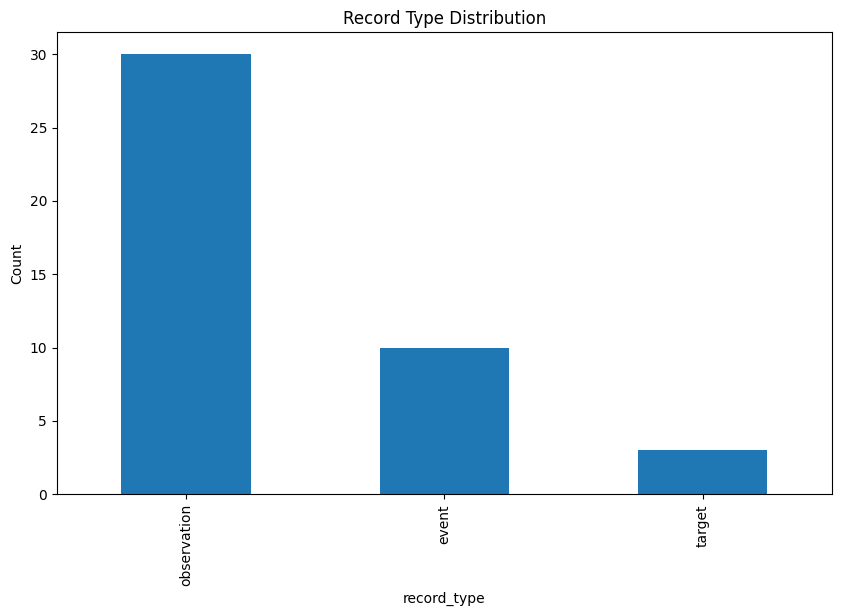

In [16]:
record_counts.plot(
    kind="bar",
    title="Record Type Distribution"
)

plt.ylabel("Count")
plt.show()

## Pillar Distribution

In [17]:
pillar_counts = data["pillar"].value_counts(dropna=False)

pillar_counts

pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

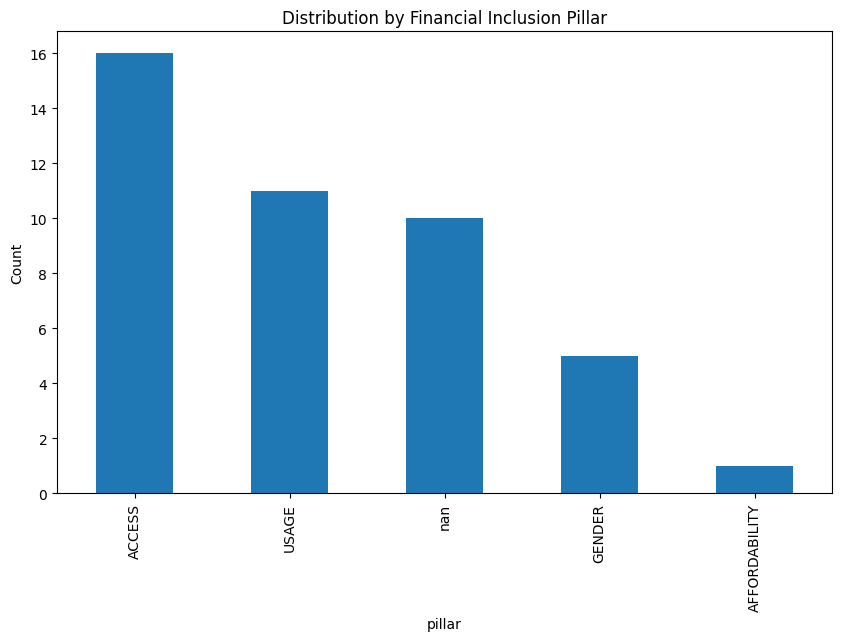

In [18]:
pillar_counts.plot(
    kind="bar",
    title="Distribution by Financial Inclusion Pillar"
)

plt.ylabel("Count")
plt.show()

## Source Type Distribution

In [19]:
source_counts = data["source_type"].value_counts(dropna=False)

source_counts

source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

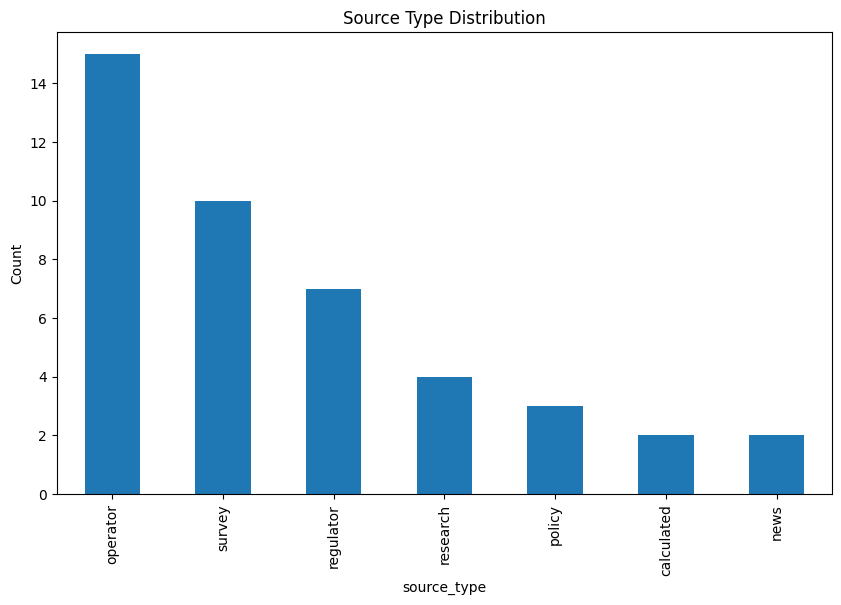

In [20]:
source_counts.plot(
    kind="bar",
    title="Source Type Distribution"
)

plt.ylabel("Count")
plt.show()

## Confidence Distribution

In [21]:
confidence_counts = data["confidence"].value_counts(dropna=False)

confidence_counts

confidence
high      40
medium     3
Name: count, dtype: int64

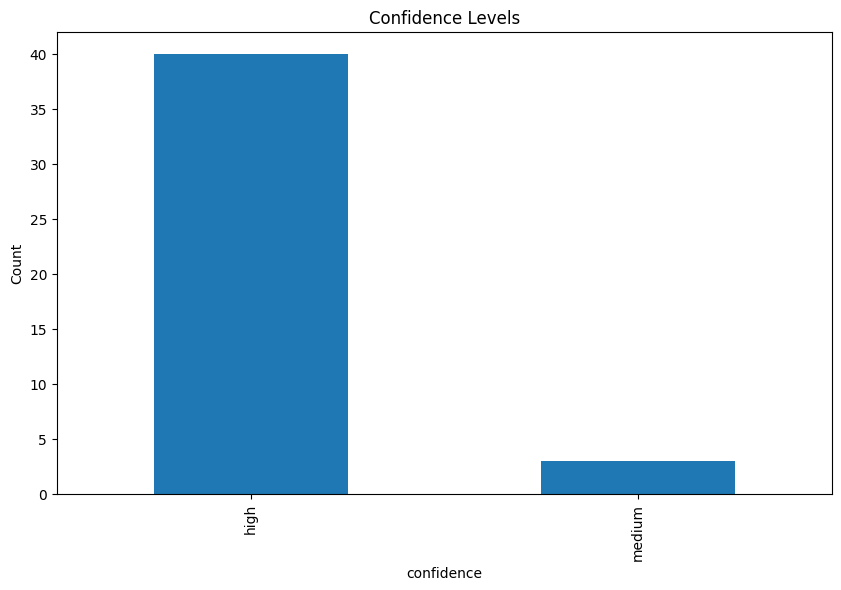

In [22]:
confidence_counts.plot(
    kind="bar",
    title="Confidence Levels"
)

plt.ylabel("Count")
plt.show()

## Observation Dataset

In [23]:
observations = data[
    data["record_type"]=="observation"
].copy()

observations.shape

(30, 34)

## Observation Timeline

In [24]:
observations = data.query(
    "record_type=='observation'"
).copy()

observations["observation_date"] = pd.to_datetime(
    observations["observation_date"]
)

print(
    "Earliest:",
    observations["observation_date"].min()
)

print(
    "Latest:",
    observations["observation_date"].max()
)

Earliest: 2014-12-31 00:00:00
Latest: 2025-12-31 00:00:00


## Observation Timeline Plot

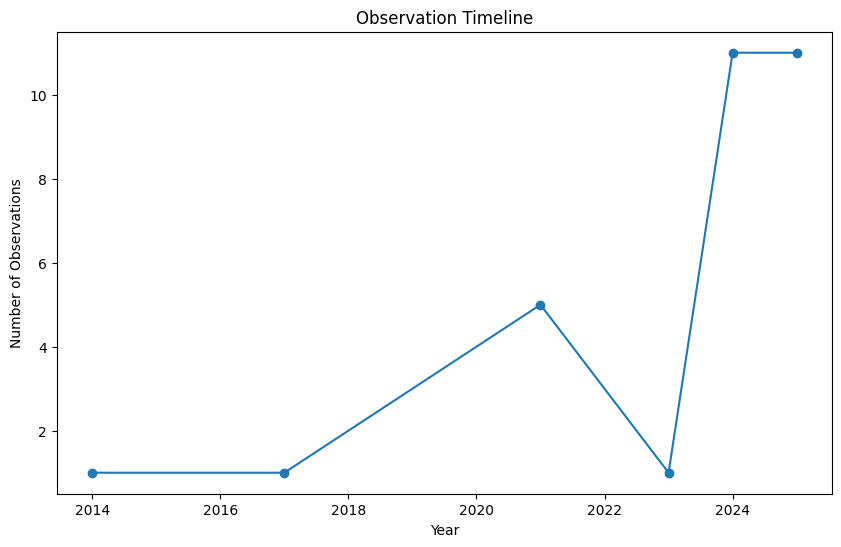

In [25]:
timeline = (
    observations
    .groupby(observations["observation_date"].dt.year)
    .size()
)

timeline.plot(marker="o")

plt.title("Observation Timeline")
plt.xlabel("Year")
plt.ylabel("Number of Observations")

plt.show()

## Indicator Coverage

In [26]:
indicator_counts = (
    observations
    .groupby("indicator_code")
    .size()
    .sort_values(ascending=False)
)

indicator_counts

indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_4G_COV            2
ACC_MM_ACCOUNT        2
GEN_GAP_ACC           2
USG_P2P_COUNT         2
ACC_MOBILE_PEN        1
GEN_GAP_MOBILE        1
GEN_MM_SHARE          1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_MPESA_ACTIVE      1
USG_CROSSOVER         1
USG_MPESA_USERS       1
USG_P2P_VALUE         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
dtype: int64

## Indicators by Pillar

In [27]:
pd.crosstab(
    observations["pillar"],
    observations["indicator_code"]
)

indicator_code,ACC_4G_COV,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,GEN_GAP_MOBILE,GEN_MM_SHARE,USG_ACTIVE_RATE,USG_ATM_COUNT,USG_ATM_VALUE,USG_CROSSOVER,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS,USG_TELEBIRR_VALUE
pillar,,,,,,,,,,,,,,,,,,,
ACCESS,2,3,2,1,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AFFORDABILITY,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
GENDER,0,0,0,0,0,0,2,1,1,0,0,0,0,0,0,0,0,0,0
USAGE,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,2,1,1,1


## Impact Links

In [33]:
print("Impact Sheet Shape:", impact_links.shape)

impact_links.head()

Impact Sheet Shape: (14, 35)


,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [34]:
impact_links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            14 non-null     object        
 1   parent_id            14 non-null     object        
 2   record_type          14 non-null     object        
 3   category             0 non-null      float64       
 4   pillar               14 non-null     object        
 5   indicator            14 non-null     object        
 6   indicator_code       0 non-null      float64       
 7   indicator_direction  0 non-null      float64       
 8   value_numeric        12 non-null     float64       
 9   value_text           0 non-null      float64       
 10  value_type           14 non-null     object        
 11  unit                 14 non-null     object        
 12  observation_date     14 non-null     datetime64[ns]
 13  period_start         0 non-null      

## Relationship Types

In [35]:
impact_links["relationship_type"].value_counts()

relationship_type
direct      9
indirect    4
enabling    1
Name: count, dtype: int64

## Events Dataset

In [28]:
events = data[
    data["record_type"]=="event"
].copy()

events

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaT,NaT,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,NaN,2022-08-01,NaT,NaT,2022,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,NaN,2023-08-01,NaT,NaT,2023,all,national,NaN,Safaricom,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Second mobile money entrant,NaN
36,EVT_0004,event,infrastructure,NaN,Fayda Digital ID Program Rollout,EVT_FAYDA,NaN,NaN,Launched,categorical,NaN,2024-01-01,NaT,NaT,2024,all,national,NaN,NIDP,regulator,https://www.id.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National biometric digital ID system,NaN
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,NaN,2024-07-29,NaT,NaT,2024,all,national,NaN,NBE,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Birr float introduced,NaN
38,EVT_0006,event,milestone,NaN,P2P Transaction Count Surpasses ATM,EVT_CROSSOVER,NaN,NaN,Achieved,categorical,NaN,2024-10-01,NaT,NaT,FY2024/25,all,national,NaN,EthSwitch,operator,https://ethswitch.com/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Historic: digital > cash for first time,NaN
39,EVT_0007,event,partnership,NaN,M-Pesa EthSwitch Integration,EVT_MPESA_INTEROP,NaN,NaN,Launched,categorical,NaN,2025-10-27,NaT,NaT,FY2025/26,all,national,NaN,EthSwitch,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Full interoperability for M-Pesa,NaN
40,EVT_0008,event,infrastructure,NaN,EthioPay Instant Payment System Launch,EVT_ETHIOPAY,NaN,NaN,Launched,categorical,NaN,2025-12-18,NaT,NaT,FY2025/26,all,national,NaN,NBE/EthSwitch,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National real-time payment system,NaN
41,EVT_0009,event,policy,NaN,NFIS-II Strategy Launch,EVT_NFIS2,NaN,NaN,Launched,categorical,NaN,2021-09-01,2021-09-01,2025-06-30,2021,all,national,NaN,NBE,regulator,https://nbe.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,5-year national financial inclusion strategy,NaN
42,EVT_0010,event,pricing,NaN,Safaricom Ethiopia Price Increase,EVT_SAFCOM_PRICE,NaN,NaN,Implemented,categorical,NaN,2025-12-15,NaT,NaT,2025,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Data and voice prices increased 20-82%,NaN


## Events by Category

In [29]:
events["category"].value_counts()

category
product_launch    2
infrastructure    2
policy            2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64

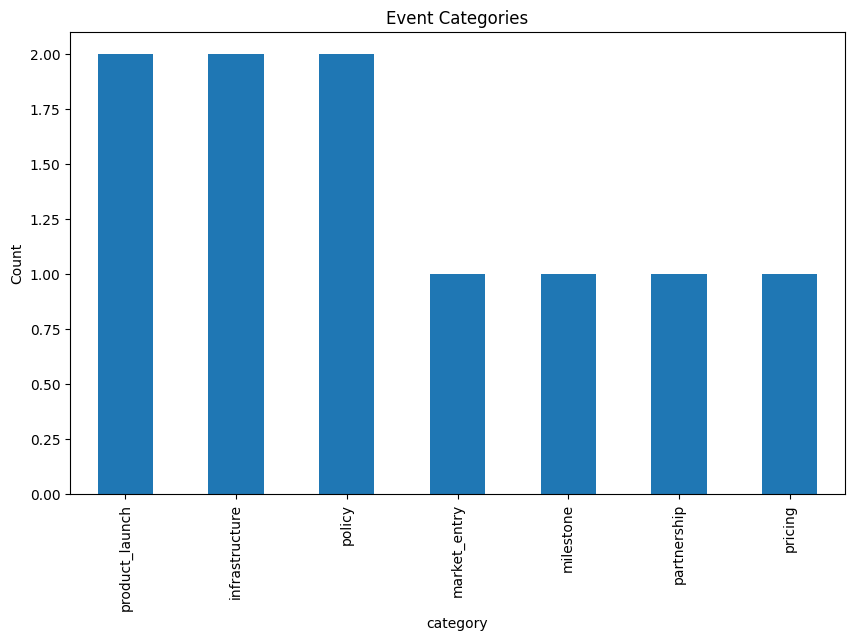

In [30]:
events["category"].value_counts().plot(
    kind="bar",
    title="Event Categories"
)

plt.ylabel("Count")
plt.show()

## Event Timeline

In [31]:
events["observation_date"] = pd.to_datetime(
    events["observation_date"]
)

events = events.sort_values("observation_date")

events[
    [
        "indicator",
        "category",
        "observation_date"
    ]
]

,indicator,category,observation_date
33,Telebirr Launch,product_launch,2021-05-17
41,NFIS-II Strategy Launch,policy,2021-09-01
34,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01
35,M-Pesa Ethiopia Launch,product_launch,2023-08-01
36,Fayda Digital ID Program Rollout,infrastructure,2024-01-01
37,Foreign Exchange Liberalization,policy,2024-07-29
38,P2P Transaction Count Surpasses ATM,milestone,2024-10-01
39,M-Pesa EthSwitch Integration,partnership,2025-10-27
42,Safaricom Ethiopia Price Increase,pricing,2025-12-15
40,EthioPay Instant Payment System Launch,infrastructure,2025-12-18


In [32]:
# Event records
events = data[data["record_type"] == "event"].copy()

events = events[
    [
        "record_id",
        "indicator",
        "category",
        "observation_date",
        "source_name",
        "confidence"
    ]
]

events.head()

,record_id,indicator,category,observation_date,source_name,confidence
33,EVT_0001,Telebirr Launch,product_launch,2021-05-17,Ethio Telecom,high
34,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,News,high
35,EVT_0003,M-Pesa Ethiopia Launch,product_launch,2023-08-01,Safaricom,high
36,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,NIDP,high
37,EVT_0005,Foreign Exchange Liberalization,policy,2024-07-29,NBE,high


## Connect Events to Impact Links

In [36]:
event_impacts = impact_links.merge(
    events,
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("_impact", "_event")
)

event_impacts.head()

,record_id_impact,parent_id,record_type,category_impact,pillar,indicator_impact,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date_impact,period_start,period_end,fiscal_year,gender,location,region,source_name_impact,source_type,source_url,confidence_impact,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,record_id_event,indicator_event,category_event,observation_date_event,source_name_event,confidence_event
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years,EVT_0001,Telebirr Launch,product_launch,2021-05-17,Ethio Telecom,high
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition,EVT_0001,Telebirr Launch,product_launch,2021-05-17,Ethio Telecom,high
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel,EVT_0001,Telebirr Launch,product_launch,2021-05-17,Ethio Telecom,high
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,News,high
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,News,high


## Display the Relationships

In [37]:
event_impacts = event_impacts.rename(columns={
    "indicator_event": "indicator",
    "category_event": "category"
})

event_impacts[
    [
        "indicator",
        "category",
        "pillar",
        "related_indicator",
        "relationship_type",
        "impact_direction",
        "impact_magnitude",
        "lag_months"
    ]
]

,indicator,category,pillar,related_indicator,relationship_type,impact_direction,impact_magnitude,lag_months
0,Telebirr Launch,product_launch,ACCESS,ACC_OWNERSHIP,direct,increase,high,12
1,Telebirr Launch,product_launch,USAGE,USG_TELEBIRR_USERS,direct,increase,high,3
2,Telebirr Launch,product_launch,USAGE,USG_P2P_COUNT,direct,increase,high,6
3,Safaricom Ethiopia Commercial Launch,market_entry,ACCESS,ACC_4G_COV,direct,increase,medium,12
4,Safaricom Ethiopia Commercial Launch,market_entry,AFFORDABILITY,AFF_DATA_INCOME,indirect,decrease,medium,12
5,M-Pesa Ethiopia Launch,product_launch,USAGE,USG_MPESA_USERS,direct,increase,high,3
6,M-Pesa Ethiopia Launch,product_launch,ACCESS,ACC_MM_ACCOUNT,direct,increase,medium,6
7,Fayda Digital ID Program Rollout,infrastructure,ACCESS,ACC_OWNERSHIP,enabling,increase,medium,24
8,Fayda Digital ID Program Rollout,infrastructure,GENDER,GEN_GAP_ACC,indirect,decrease,medium,24
9,Foreign Exchange Liberalization,policy,AFFORDABILITY,AFF_DATA_INCOME,indirect,increase,high,3


## How many impacts does each event have?

In [38]:
event_summary = (
    event_impacts
    .groupby(["indicator", "category"])
    .agg(
        impacts=("related_indicator", "count"),
        pillars=("pillar", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
)

event_summary

,indicator,category,impacts,pillars
0,EthioPay Instant Payment System Launch,infrastructure,1,USAGE
1,Fayda Digital ID Program Rollout,infrastructure,2,"ACCESS, GENDER"
2,Foreign Exchange Liberalization,policy,1,AFFORDABILITY
3,M-Pesa EthSwitch Integration,partnership,2,USAGE
4,M-Pesa Ethiopia Launch,product_launch,2,"ACCESS, USAGE"
5,Safaricom Ethiopia Commercial Launch,market_entry,2,"ACCESS, AFFORDABILITY"
6,Safaricom Ethiopia Price Increase,pricing,1,AFFORDABILITY
7,Telebirr Launch,product_launch,3,"ACCESS, USAGE"


## Visualize Event Categories

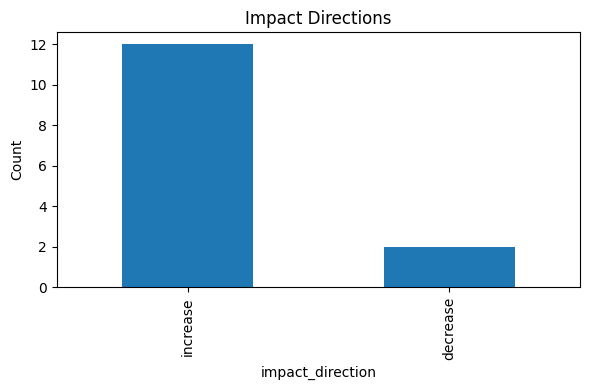

In [39]:
event_impacts["impact_direction"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Impact Directions")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Additional Observations

In [40]:
new_observations = pd.DataFrame([
    
    # --------------------------------------------------------
    # TELEBIRR - ACCESS
    # --------------------------------------------------------
    {
        "record_id": "REC_ENRICH_001",
        "record_type": "observation",
        "category": None,
        "pillar": "ACCESS",
        "indicator": "Telebirr Registered Users",
        "indicator_code": "TBRR_USERS",
        "indicator_direction": "higher_better",
        "value_numeric": 54.84,
        "value_text": None,
        "value_type": "count",
        "unit": "million users",
        "observation_date": "2025-06-30",
        "period_start": "2024-07-01",
        "period_end": "2025-06-30",
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Ethio telecom FY 2024/25 Annual Performance",
        "source_type": "operator",
        "source_url": "https://www.ethiotelecom.et/2024-25-fiscal-year-annual-performance-and-three-year-lead-growth-strategy-performance/3/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The total number of telebirr service users reached 54.84 million.",
        "notes": "Large-scale mobile money user growth is a leading indicator of financial access and digital financial ecosystem expansion."
    },

    # --------------------------------------------------------
    # TELEBIRR - AGENTS
    # --------------------------------------------------------
    {
        "record_id": "REC_ENRICH_002",
        "record_type": "observation",
        "category": None,
        "pillar": "ACCESS",
        "indicator": "Telebirr Agents",
        "indicator_code": "TBRR_AGENTS",
        "indicator_direction": "higher_better",
        "value_numeric": 320300,
        "value_text": None,
        "value_type": "count",
        "unit": "agents",
        "observation_date": "2025-06-30",
        "period_start": "2024-07-01",
        "period_end": "2025-06-30",
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Ethio telecom FY 2024/25 Annual Performance",
        "source_type": "operator",
        "source_url": "https://www.ethiotelecom.et/2024-25-fiscal-year-annual-performance-and-three-year-lead-growth-strategy-performance/3/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "This expanded the total number of agents to 320.3 thousand.",
        "notes": "Agent density improves physical access to digital financial services, particularly for users without nearby bank branches."
    },

    # --------------------------------------------------------
    # TELEBIRR - MERCHANTS
    # --------------------------------------------------------
    {
        "record_id": "REC_ENRICH_003",
        "record_type": "observation",
        "category": None,
        "pillar": "USAGE",
        "indicator": "Telebirr Merchants",
        "indicator_code": "TBRR_MERCHANTS",
        "indicator_direction": "higher_better",
        "value_numeric": 310100,
        "value_text": None,
        "value_type": "count",
        "unit": "merchants",
        "observation_date": "2025-06-30",
        "period_start": "2024-07-01",
        "period_end": "2025-06-30",
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Ethio telecom FY 2024/25 Annual Performance",
        "source_type": "operator",
        "source_url": "https://www.ethiotelecom.et/2024-25-fiscal-year-annual-performance-and-three-year-lead-growth-strategy-performance/3/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The total number of merchants reached 310.1 thousand.",
        "notes": "Merchant acceptance is a direct enabler of digital payment usage."
    },

    # --------------------------------------------------------
    # TELEBIRR - TRANSACTION VALUE
    # --------------------------------------------------------
    {
        "record_id": "REC_ENRICH_004",
        "record_type": "observation",
        "category": None,
        "pillar": "USAGE",
        "indicator": "Telebirr Annual Electronic Money Transactions",
        "indicator_code": "TBRR_TXN_VALUE",
        "indicator_direction": "higher_better",
        "value_numeric": 2.38,
        "value_text": None,
        "value_type": "currency_etb",
        "unit": "trillion ETB",
        "observation_date": "2025-06-30",
        "period_start": "2024-07-01",
        "period_end": "2025-06-30",
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Ethio telecom FY 2024/25 Annual Performance",
        "source_type": "operator",
        "source_url": "https://www.ethiotelecom.et/2024-25-fiscal-year-annual-performance-and-three-year-lead-growth-strategy-performance/3/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "2.38 trillion ETB electronic money transactions was made in telebirr.",
        "notes": "Transaction value captures actual usage intensity rather than simple account registration."
    },

    # --------------------------------------------------------
    # TELEBIRR - NEW USERS
    # --------------------------------------------------------
    {
        "record_id": "REC_ENRICH_005",
        "record_type": "observation",
        "category": None,
        "pillar": "ACCESS",
        "indicator": "Annual Growth in Telebirr Users",
        "indicator_code": "TBRR_USER_GROWTH",
        "indicator_direction": "higher_better",
        "value_numeric": 15.3,
        "value_text": None,
        "value_type": "percentage",
        "unit": "%",
        "observation_date": "2025-06-30",
        "period_start": "2024-07-01",
        "period_end": "2025-06-30",
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Ethio telecom FY 2024/25 Annual Performance",
        "source_type": "operator",
        "source_url": "https://www.ethiotelecom.et/2024-25-fiscal-year-annual-performance-and-three-year-lead-growth-strategy-performance/3/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "This shows a 15.3% growth compared to the previous fiscal year.",
        "notes": "Annual growth rate can serve as a leading indicator for future account ownership expansion."
    },

    # --------------------------------------------------------
    # SAFARICOM ACTIVE CUSTOMERS
    # --------------------------------------------------------
    {
        "record_id": "REC_ENRICH_006",
        "record_type": "observation",
        "category": None,
        "pillar": "ACCESS",
        "indicator": "Safaricom Ethiopia 90-Day Active Customers",
        "indicator_code": "SAF_ACTIVE_USERS",
        "indicator_direction": "higher_better",
        "value_numeric": 10.0,
        "value_text": None,
        "value_type": "count",
        "unit": "million users",
        "observation_date": "2025-07-01",
        "period_start": None,
        "period_end": None,
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Safaricom Ethiopia",
        "source_type": "operator",
        "source_url": "https://www.safaricom.et/en/whats-new/latest/news-and-blogs/safaricom-ethiopia-hits-10-million-customers-demonstrates-strong-performance-investment-and-job-creation",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "Safaricom Ethiopia reaches a major milestone serving 10 million 90 days active customers across Ethiopia.",
        "notes": "Mobile connectivity expansion creates the infrastructure base for mobile money and digital payment adoption."
    },

    # --------------------------------------------------------
    # DIGITAL TRANSACTION VALUE
    # --------------------------------------------------------
    {
        "record_id": "REC_ENRICH_007",
        "record_type": "observation",
        "category": None,
        "pillar": "USAGE",
        "indicator": "National Digital Transaction Value",
        "indicator_code": "NATIONAL_DIGITAL_TXN_VALUE",
        "indicator_direction": "higher_better",
        "value_numeric": 9.7,
        "value_text": None,
        "value_type": "currency_etb",
        "unit": "trillion ETB",
        "observation_date": "2024-06-30",
        "period_start": "2023-07-01",
        "period_end": "2024-06-30",
        "fiscal_year": 2024,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia - NDPS 2.0",
        "source_type": "regulator",
        "source_url": "https://nbe.gov.et/nbe_news/ethiopia-launches-phase-two-of-national-digital-payments-strategy-building-on-strong-momentum-from-phase-one/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "In the 2023/24 fiscal year, Ethiopia recorded a substantial 9.7 trillion Birr in digital transactions.",
        "notes": "Provides a national-level measure of digital payment usage and complements demand-side Findex indicators."
    },

    # --------------------------------------------------------
    # MOBILE MONEY ACCOUNTS
    # --------------------------------------------------------
    {
        "record_id": "REC_ENRICH_008",
        "record_type": "observation",
        "category": None,
        "pillar": "ACCESS",
        "indicator": "Mobile Money Accounts",
        "indicator_code": "MOBILE_MONEY_ACCOUNTS",
        "indicator_direction": "higher_better",
        "value_numeric": 128.5,
        "value_text": None,
        "value_type": "count",
        "unit": "million accounts",
        "observation_date": "2024-12-31",
        "period_start": None,
        "period_end": None,
        "fiscal_year": 2024,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia - NDPS 2.0",
        "source_type": "regulator",
        "source_url": "https://nbe.gov.et/nbe_news/ethiopia-launches-phase-two-of-national-digital-payments-strategy-building-on-strong-momentum-from-phase-one/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The number of mobile money accounts expanded from under 1 million in 2020 to more than 128.5 million users by December 31, 2024.",
        "notes": "Mobile money account growth is an important supply-side measure of financial access, although registered accounts may exceed unique active users."
    }
])

new_observations["observation_date"] = pd.to_datetime(
    new_observations["observation_date"]
)

new_observations["period_start"] = pd.to_datetime(
    new_observations["period_start"]
)

new_observations["period_end"] = pd.to_datetime(
    new_observations["period_end"]
)

## Additional Events

In [41]:
new_events = pd.DataFrame([

    # --------------------------------------------------------
    # NDPS 2.0
    # --------------------------------------------------------
    {
        "record_id": "EVT_ENRICH_001",
        "record_type": "event",
        "category": "policy",
        "pillar": None,
        "indicator": "National Digital Payments Strategy 2.0 Launched",
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": "2025-03-28",
        "period_start": None,
        "period_end": None,
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia",
        "source_type": "policy",
        "source_url": "https://nbe.gov.et/nbe_news/ethiopia-launches-phase-two-of-national-digital-payments-strategy-building-on-strong-momentum-from-phase-one/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The National Bank of Ethiopia today announced the launch of Phase Two of the National Digital Payments Strategy (NDPS 2.0).",
        "notes": "Major national policy event focused on interoperability, digital ID integration, merchant acceptance, and digital payment usage."
    },

    # --------------------------------------------------------
    # INTEROPERABLE QR STANDARD
    # --------------------------------------------------------
    {
        "record_id": "EVT_ENRICH_002",
        "record_type": "event",
        "category": "infrastructure",
        "pillar": None,
        "indicator": "National Interoperable QR Payment Standard Introduced",
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": "2024-12-31",
        "period_start": None,
        "period_end": None,
        "fiscal_year": 2024,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia",
        "source_type": "regulator",
        "source_url": "https://nbe.gov.et/eipqrc/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The introduction of a national standard for interoperable QR code payments supports secure, efficient, and widespread use of QR payments.",
        "notes": "Interoperable QR infrastructure can reduce fragmentation and increase merchant and consumer digital payment adoption."
    },

    # --------------------------------------------------------
    # SAFARICOM 10M CUSTOMERS
    # --------------------------------------------------------
    {
        "record_id": "EVT_ENRICH_003",
        "record_type": "milestone",
        "category": "milestone",
        "pillar": None,
        "indicator": "Safaricom Ethiopia Reaches 10 Million Active Customers",
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": "2025-07-01",
        "period_start": None,
        "period_end": None,
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Safaricom Ethiopia",
        "source_type": "operator",
        "source_url": "https://www.safaricom.et/en/whats-new/latest/news-and-blogs/safaricom-ethiopia-hits-10-million-customers-demonstrates-strong-performance-investment-and-job-creation",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "Safaricom Ethiopia reaches a major milestone serving 10 million 90 days active customers across Ethiopia.",
        "notes": "Expanding mobile connectivity increases the potential addressable population for mobile money and digital payment services."
    },

    # --------------------------------------------------------
    # NDPS 2026-2030
    # --------------------------------------------------------
    {
        "record_id": "EVT_ENRICH_004",
        "record_type": "policy",
        "category": "policy",
        "pillar": None,
        "indicator": "National Digital Payments Strategy 2026-2030 Draft Launched",
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": "2025-12-09",
        "period_start": None,
        "period_end": None,
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Ethiopia Digital Payment Conference / NBE",
        "source_type": "policy",
        "source_url": "https://edpc.nbe.gov.et/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The conference marked the official launch of the National Digital Payments Strategy 2026-2030.",
        "notes": "Relevant policy event for 2026-2027 forecasting because it targets interoperability, trust, adoption, and inclusion."
    },

    # --------------------------------------------------------
    # ETHIOPIA INSTANT PAYMENT SYSTEM
    # --------------------------------------------------------
    {
        "record_id": "EVT_ENRICH_005",
        "record_type": "infrastructure",
        "category": "infrastructure",
        "pillar": None,
        "indicator": "Ethiopia Instant Payment System Launch",
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": "2025-12-09",
        "period_start": None,
        "period_end": None,
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Ethiopia Digital Payment Conference / NBE",
        "source_type": "regulator",
        "source_url": "https://edpc.nbe.gov.et/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "Launching of Instant Payment System.",
        "notes": "Instant payment infrastructure can reduce transaction friction and support higher digital payment usage."
    },

    # --------------------------------------------------------
    # TELEBIRR USER MILESTONE
    # --------------------------------------------------------
    {
        "record_id": "EVT_ENRICH_006",
        "record_type": "milestone",
        "category": "milestone",
        "pillar": None,
        "indicator": "Telebirr Reaches 54.84 Million Users",
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": "2025-06-30",
        "period_start": None,
        "period_end": None,
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Ethio telecom",
        "source_type": "operator",
        "source_url": "https://www.ethiotelecom.et/2024-25-fiscal-year-annual-performance-and-three-year-lead-growth-strategy-performance/3/",
        "confidence": "high",
        "related_indicator": None,
        "relationship_type": None,
        "impact_direction": None,
        "impact_magnitude": None,
        "impact_estimate": None,
        "lag_months": None,
        "evidence_basis": None,
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The total number of telebirr service users reached 54.84 million.",
        "notes": "Major digital finance adoption milestone that may support future growth in account ownership and usage."
    }
])

new_events["observation_date"] = pd.to_datetime(
    new_events["observation_date"]
)

## Additional Impact Links

In [42]:
new_impact_links = pd.DataFrame([

    # --------------------------------------------------------
    # NDPS 2.0 → ACCESS
    # --------------------------------------------------------
    {
        "record_id": "IMP_ENRICH_001",
        "parent_id": "EVT_ENRICH_001",
        "record_type": "impact_link",
        "category": None,
        "pillar": "ACCESS",
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": None,
        "period_start": None,
        "period_end": None,
        "fiscal_year": None,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia",
        "source_type": "policy",
        "source_url": "https://nbe.gov.et/nbe_news/ethiopia-launches-phase-two-of-national-digital-payments-strategy-building-on-strong-momentum-from-phase-one/",
        "confidence": "high",
        "related_indicator": "ACC_OWNERSHIP",
        "relationship_type": "enabling",
        "impact_direction": "increase",
        "impact_magnitude": "medium",
        "impact_estimate": None,
        "lag_months": 12,
        "evidence_basis": "theoretical",
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "Phase Two will focus on expanding digital ID integration and creating an inclusive digital financial ecosystem.",
        "notes": "Policy creates enabling conditions for account ownership through digital identity and expanded digital financial infrastructure."
    },

    # --------------------------------------------------------
    # NDPS 2.0 → USAGE
    # --------------------------------------------------------
    {
        "record_id": "IMP_ENRICH_002",
        "parent_id": "EVT_ENRICH_001",
        "record_type": "impact_link",
        "category": None,
        "pillar": "USAGE",
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": None,
        "period_start": None,
        "period_end": None,
        "fiscal_year": None,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia",
        "source_type": "policy",
        "source_url": "https://nbe.gov.et/nbe_news/ethiopia-launches-phase-two-of-national-digital-payments-strategy-building-on-strong-momentum-from-phase-one/",
        "confidence": "high",
        "related_indicator": "USG_DIGITAL_PAYMENT",
        "relationship_type": "enabling",
        "impact_direction": "increase",
        "impact_magnitude": "high",
        "impact_estimate": None,
        "lag_months": 12,
        "evidence_basis": "theoretical",
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "Phase Two will focus on deepening usage of digital payments, ensuring full interoperability, and accelerating merchant acceptance.",
        "notes": "Directly aligned with the Usage forecasting target."
    },

    # --------------------------------------------------------
    # INTEROPERABLE QR → USAGE
    # --------------------------------------------------------
    {
        "record_id": "IMP_ENRICH_003",
        "parent_id": "EVT_ENRICH_002",
        "record_type": "impact_link",
        "category": None,
        "pillar": "USAGE",
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": None,
        "period_start": None,
        "period_end": None,
        "fiscal_year": None,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia",
        "source_type": "regulator",
        "source_url": "https://nbe.gov.et/eipqrc/",
        "confidence": "high",
        "related_indicator": "USG_DIGITAL_PAYMENT",
        "relationship_type": "direct",
        "impact_direction": "increase",
        "impact_magnitude": "medium",
        "impact_estimate": None,
        "lag_months": 6,
        "evidence_basis": "theoretical",
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "This initiative aims to enhance digital payment accessibility, reduce cash dependence, and ensure secure, seamless transactions.",
        "notes": "Interoperable QR payments reduce fragmentation and make digital payments easier for consumers and merchants."
    },

    # --------------------------------------------------------
    # SAFARICOM GROWTH → ACCESS
    # --------------------------------------------------------
    {
        "record_id": "IMP_ENRICH_004",
        "parent_id": "EVT_ENRICH_003",
        "record_type": "impact_link",
        "category": None,
        "pillar": "ACCESS",
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": None,
        "period_start": None,
        "period_end": None,
        "fiscal_year": None,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Safaricom Ethiopia",
        "source_type": "operator",
        "source_url": "https://www.safaricom.et/en/whats-new/latest/news-and-blogs/safaricom-ethiopia-hits-10-million-customers-demonstrates-strong-performance-investment-and-job-creation",
        "confidence": "high",
        "related_indicator": "ACC_OWNERSHIP",
        "relationship_type": "enabling",
        "impact_direction": "increase",
        "impact_magnitude": "medium",
        "impact_estimate": None,
        "lag_months": 12,
        "evidence_basis": "theoretical",
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "Safaricom Ethiopia reaches a major milestone serving 10 million 90 days active customers across Ethiopia.",
        "notes": "Expanded mobile connectivity increases the population that can potentially access mobile financial services."
    },

    # --------------------------------------------------------
    # SAFARICOM GROWTH → USAGE
    # --------------------------------------------------------
    {
        "record_id": "IMP_ENRICH_005",
        "parent_id": "EVT_ENRICH_003",
        "record_type": "impact_link",
        "category": None,
        "pillar": "USAGE",
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": None,
        "period_start": None,
        "period_end": None,
        "fiscal_year": None,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Safaricom Ethiopia",
        "source_type": "operator",
        "source_url": "https://www.safaricom.et/en/whats-new/latest/news-and-blogs/safaricom-ethiopia-hits-10-million-customers-demonstrates-strong-performance-investment-and-job-creation",
        "confidence": "high",
        "related_indicator": "USG_DIGITAL_PAYMENT",
        "relationship_type": "enabling",
        "impact_direction": "increase",
        "impact_magnitude": "medium",
        "impact_estimate": None,
        "lag_months": 12,
        "evidence_basis": "theoretical",
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The milestone supports Ethiopia's digital transformation through inclusive mobile connectivity.",
        "notes": "Greater connectivity can support digital payment adoption when combined with mobile money availability and merchant acceptance."
    },

    # --------------------------------------------------------
    # NDPS 2026-2030 → ACCESS
    # --------------------------------------------------------
    {
        "record_id": "IMP_ENRICH_006",
        "parent_id": "EVT_ENRICH_004",
        "record_type": "impact_link",
        "category": None,
        "pillar": "ACCESS",
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": None,
        "period_start": None,
        "period_end": None,
        "fiscal_year": None,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia",
        "source_type": "policy",
        "source_url": "https://edpc.nbe.gov.et/",
        "confidence": "high",
        "related_indicator": "ACC_OWNERSHIP",
        "relationship_type": "enabling",
        "impact_direction": "increase",
        "impact_magnitude": "high",
        "impact_estimate": None,
        "lag_months": 12,
        "evidence_basis": "theoretical",
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The National Digital Payments Strategy 2026-2030 is a five-year roadmap toward a more inclusive, interoperable, and resilient digital financial ecosystem.",
        "notes": "Relevant for forecasting 2026-2027 because the strategy is specifically designed to expand inclusion."
    },

    # --------------------------------------------------------
    # NDPS 2026-2030 → USAGE
    # --------------------------------------------------------
    {
        "record_id": "IMP_ENRICH_007",
        "parent_id": "EVT_ENRICH_004",
        "record_type": "impact_link",
        "category": None,
        "pillar": "USAGE",
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": None,
        "period_start": None,
        "period_end": None,
        "fiscal_year": None,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia",
        "source_type": "policy",
        "source_url": "https://edpc.nbe.gov.et/",
        "confidence": "high",
        "related_indicator": "USG_DIGITAL_PAYMENT",
        "relationship_type": "enabling",
        "impact_direction": "increase",
        "impact_magnitude": "high",
        "impact_estimate": None,
        "lag_months": 12,
        "evidence_basis": "theoretical",
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The strategy aims to accelerate adoption and deepen usage of digital payments.",
        "notes": "Directly relevant to the Usage forecasting target."
    },

    # --------------------------------------------------------
    # INSTANT PAYMENT SYSTEM → USAGE
    # --------------------------------------------------------
    {
        "record_id": "IMP_ENRICH_008",
        "parent_id": "EVT_ENRICH_005",
        "record_type": "impact_link",
        "category": None,
        "pillar": "USAGE",
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": None,
        "period_start": None,
        "period_end": None,
        "fiscal_year": None,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia",
        "source_type": "regulator",
        "source_url": "https://edpc.nbe.gov.et/",
        "confidence": "high",
        "related_indicator": "USG_DIGITAL_PAYMENT",
        "relationship_type": "direct",
        "impact_direction": "increase",
        "impact_magnitude": "high",
        "impact_estimate": None,
        "lag_months": 6,
        "evidence_basis": "theoretical",
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "Launching of Instant Payment System.",
        "notes": "Instant payment infrastructure is expected to reduce payment friction and increase digital transaction frequency."
    },

    # --------------------------------------------------------
    # TELEBIRR MILESTONE → ACCESS
    # --------------------------------------------------------
    {
        "record_id": "IMP_ENRICH_009",
        "parent_id": "EVT_ENRICH_006",
        "record_type": "impact_link",
        "category": None,
        "pillar": "ACCESS",
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": None,
        "period_start": None,
        "period_end": None,
        "fiscal_year": None,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Ethio telecom",
        "source_type": "operator",
        "source_url": "https://www.ethiotelecom.et/2024-25-fiscal-year-annual-performance-and-three-year-lead-growth-strategy-performance/3/",
        "confidence": "high",
        "related_indicator": "ACC_OWNERSHIP",
        "relationship_type": "indirect",
        "impact_direction": "increase",
        "impact_magnitude": "medium",
        "impact_estimate": None,
        "lag_months": 12,
        "evidence_basis": "empirical",
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "The total number of telebirr service users reached 54.84 million.",
        "notes": "Large-scale mobile money adoption can contribute to broader financial account ownership."
    },

    # --------------------------------------------------------
    # TELEBIRR MILESTONE → USAGE
    # --------------------------------------------------------
    {
        "record_id": "IMP_ENRICH_010",
        "parent_id": "EVT_ENRICH_006",
        "record_type": "impact_link",
        "category": None,
        "pillar": "USAGE",
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": None,
        "value_type": None,
        "unit": None,
        "observation_date": None,
        "period_start": None,
        "period_end": None,
        "fiscal_year": None,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "Ethio telecom",
        "source_type": "operator",
        "source_url": "https://www.ethiotelecom.et/2024-25-fiscal-year-annual-performance-and-three-year-lead-growth-strategy-performance/3/",
        "confidence": "high",
        "related_indicator": "USG_DIGITAL_PAYMENT",
        "relationship_type": "indirect",
        "impact_direction": "increase",
        "impact_magnitude": "high",
        "impact_estimate": None,
        "lag_months": 6,
        "evidence_basis": "empirical",
        "comparable_country": None,
        "collected_by": "Semegn Mulugeta",
        "collection_date": "2026-07-18",
        "original_text": "2.38 trillion ETB electronic money transactions was made in telebirr.",
        "notes": "The scale of electronic-money transactions indicates strong growth in digital financial usage."
    }
])

## Combine the Enriched Data

In [43]:
# Combine original observations/events with new records

data_enriched = pd.concat(
    [
        data,
        new_observations,
        new_events
    ],
    ignore_index=True
)

print("Original records:", len(data))
print("New observations:", len(new_observations))
print("New events:", len(new_events))
print("Enriched records:", len(data_enriched))

Original records: 43
New observations: 8
New events: 6
Enriched records: 57


C:\Users\hp\AppData\Local\Temp\ipykernel_11852\713786213.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_enriched = pd.concat(
C:\Users\hp\AppData\Local\Temp\ipykernel_11852\713786213.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_enriched = pd.concat(
C:\Users\hp\AppData\Local\Temp\ipykernel_11852\713786213.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA c

In [44]:
impact_links_enriched = pd.concat(
    [
        impact_links,
        new_impact_links
    ],
    ignore_index=True
)

print("Original impact links:", len(impact_links))
print("New impact links:", len(new_impact_links))
print("Enriched impact links:", len(impact_links_enriched))

Original impact links: 14
New impact links: 10
Enriched impact links: 24


C:\Users\hp\AppData\Local\Temp\ipykernel_11852\3352330149.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  impact_links_enriched = pd.concat(


## Validate the New Enrichment

In [45]:
print(
    data_enriched[
        data_enriched["record_id"].str.startswith("REC_ENRICH")
    ][
        [
            "record_id",
            "record_type",
            "pillar",
            "indicator",
            "indicator_code",
            "value_numeric",
            "observation_date"
        ]
    ]
)

         record_id  record_type  pillar  \
43  REC_ENRICH_001  observation  ACCESS   
44  REC_ENRICH_002  observation  ACCESS   
45  REC_ENRICH_003  observation   USAGE   
46  REC_ENRICH_004  observation   USAGE   
47  REC_ENRICH_005  observation  ACCESS   
48  REC_ENRICH_006  observation  ACCESS   
49  REC_ENRICH_007  observation   USAGE   
50  REC_ENRICH_008  observation  ACCESS   

                                        indicator              indicator_code  \
43                      Telebirr Registered Users                  TBRR_USERS   
44                                Telebirr Agents                 TBRR_AGENTS   
45                             Telebirr Merchants              TBRR_MERCHANTS   
46  Telebirr Annual Electronic Money Transactions              TBRR_TXN_VALUE   
47                Annual Growth in Telebirr Users            TBRR_USER_GROWTH   
48     Safaricom Ethiopia 90-Day Active Customers            SAF_ACTIVE_USERS   
49             National Digital Transaction V

In [46]:
print(
    data_enriched[
        data_enriched["record_id"].str.startswith("EVT_ENRICH")
    ][
        [
            "record_id",
            "record_type",
            "category",
            "pillar",
            "indicator",
            "observation_date"
        ]
    ]
)

         record_id     record_type        category pillar  \
51  EVT_ENRICH_001           event          policy   None   
52  EVT_ENRICH_002           event  infrastructure   None   
53  EVT_ENRICH_003       milestone       milestone   None   
54  EVT_ENRICH_004          policy          policy   None   
55  EVT_ENRICH_005  infrastructure  infrastructure   None   
56  EVT_ENRICH_006       milestone       milestone   None   

                                            indicator observation_date  
51    National Digital Payments Strategy 2.0 Launched       2025-03-28  
52  National Interoperable QR Payment Standard Int...       2024-12-31  
53  Safaricom Ethiopia Reaches 10 Million Active C...       2025-07-01  
54  National Digital Payments Strategy 2026-2030 D...       2025-12-09  
55             Ethiopia Instant Payment System Launch       2025-12-09  
56               Telebirr Reaches 54.84 Million Users       2025-06-30  


In [47]:
print(
    impact_links_enriched[
        impact_links_enriched["record_id"].str.startswith("IMP_ENRICH")
    ][
        [
            "record_id",
            "parent_id",
            "pillar",
            "related_indicator",
            "relationship_type",
            "impact_direction",
            "impact_magnitude",
            "lag_months",
            "evidence_basis"
        ]
    ]
)

         record_id       parent_id  pillar    related_indicator  \
14  IMP_ENRICH_001  EVT_ENRICH_001  ACCESS        ACC_OWNERSHIP   
15  IMP_ENRICH_002  EVT_ENRICH_001   USAGE  USG_DIGITAL_PAYMENT   
16  IMP_ENRICH_003  EVT_ENRICH_002   USAGE  USG_DIGITAL_PAYMENT   
17  IMP_ENRICH_004  EVT_ENRICH_003  ACCESS        ACC_OWNERSHIP   
18  IMP_ENRICH_005  EVT_ENRICH_003   USAGE  USG_DIGITAL_PAYMENT   
19  IMP_ENRICH_006  EVT_ENRICH_004  ACCESS        ACC_OWNERSHIP   
20  IMP_ENRICH_007  EVT_ENRICH_004   USAGE  USG_DIGITAL_PAYMENT   
21  IMP_ENRICH_008  EVT_ENRICH_005   USAGE  USG_DIGITAL_PAYMENT   
22  IMP_ENRICH_009  EVT_ENRICH_006  ACCESS        ACC_OWNERSHIP   
23  IMP_ENRICH_010  EVT_ENRICH_006   USAGE  USG_DIGITAL_PAYMENT   

   relationship_type impact_direction impact_magnitude  lag_months  \
14          enabling         increase           medium          12   
15          enabling         increase             high          12   
16            direct         increase           medi

## Validate the parent_id Relationship

In [48]:
# Select only the event columns we actually need
event_lookup = data_enriched[
    data_enriched["record_type"] == "event"
][[
    "record_id",
    "category",
    "indicator",
    "observation_date",
    "source_name"
]].copy()

# Rename record_id so the relationship is explicit
event_lookup = event_lookup.rename(
    columns={
        "record_id": "event_id",
        "indicator": "event_name",
        "observation_date": "event_date",
        "source_name": "event_source"
    }
)

# Merge impact links to events
event_impacts_enriched = impact_links_enriched.merge(
    event_lookup,
    left_on="parent_id",
    right_on="event_id",
    how="left"
)

## Inspect the resulting columns

In [49]:
event_impacts_enriched.columns.tolist()

['record_id',
 'parent_id',
 'record_type',
 'category_x',
 'pillar',
 'indicator',
 'indicator_code',
 'indicator_direction',
 'value_numeric',
 'value_text',
 'value_type',
 'unit',
 'observation_date',
 'period_start',
 'period_end',
 'fiscal_year',
 'gender',
 'location',
 'region',
 'source_name',
 'source_type',
 'source_url',
 'confidence',
 'related_indicator',
 'relationship_type',
 'impact_direction',
 'impact_magnitude',
 'impact_estimate',
 'lag_months',
 'evidence_basis',
 'comparable_country',
 'collected_by',
 'collection_date',
 'original_text',
 'notes',
 'event_id',
 'category_y',
 'event_name',
 'event_date',
 'event_source']

## Save the dataset

In [60]:
# Save both the enriched data and impact links
with pd.ExcelWriter(
    "../data/processed/ethiopia_fi_enriched.xlsx",
    engine="openpyxl"
) as writer:

    # Main data: original records + newly added observations/events
    data_enriched.to_excel(
        writer,
        sheet_name="Data",
        index=False
    )

    # Impact links: original + newly added relationships
    impact_links_enriched.to_excel(
        writer,
        sheet_name="Impact_sheet",
        index=False
    )

print("Saved successfully to:")
print("../data/processed/ethiopia_fi_enriched.xlsx")

Saved successfully to:
../data/processed/ethiopia_fi_enriched.xlsx
